In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
import os
os.getcwd()

'C:\\Users\\Micki\\workspace\\python\\UN Project'

In [66]:
import os
os.chdir(r'C:\Users\Micki\workspace\python\UN Project')

In [67]:
gdp_df = pd.read_csv('gdp_percapita.csv')

-- Take a look at the first few and last few rows to familiarize yourself with what is contained in this dataset.

In [68]:
gdp_df.tail(10)

,Country or Area,Year,Value,Value Footnotes
8455,Zimbabwe,1999,6423.708868,NaN
8456,Zimbabwe,1998,6582.348419,NaN
8457,Zimbabwe,1997,6524.062658,NaN
8458,Zimbabwe,1996,6474.160183,NaN
8459,Zimbabwe,1995,5964.589380,NaN
8460,Zimbabwe,1994,6010.742417,NaN
8461,Zimbabwe,1993,5509.083113,NaN
8462,Zimbabwe,1992,5532.037403,NaN
8463,Zimbabwe,1991,6254.274735,NaN
8464,Zimbabwe,1990,6082.842451,NaN


How many rows and columns are in gdp_df? What are the data types of each column?

In [81]:
gdp_df.shape

(8465, 3)

In [92]:
gdp_df.dtypes

Country            object
Year                int64
GDP_Per_Capita    float64
dtype: object

Drop the Value Footnotes column and rename the remaining three to 'Country', 'Year', and 'GDP_Per_Capita'.

In [93]:
print(gdp_df.columns)

Index(['Country', 'Year', 'GDP_Per_Capita'], dtype='object')


In [94]:
gdp_df = gdp_df.rename(columns={'Country or Area': 'Country', 'Year': 'Year', 'Value': 'GDP_Per_Capita'})


How many countries have data for all years? Which countries are missing many years of data? Look at the number of observations per year. What do you notice?

In [112]:
year_counts = gdp_df.groupby('Country')['GDP_Per_Capita'].count()
total_years = gdp_df['Year'].nunique()
complete_countries = year_counts[year_counts == total_years]
print(f'total years in dataset: {total_years}')
print(f'Countries with data for all years: {len(complete_countries)}')

#Missing Data

missing_data = year_counts.sort_values()
print(missing_data.head())

#observations by year
gdp_df.groupby('Year')['GDP_Per_Capita'].count()

total years in dataset: 35
Countries with data for all years: 226
Country
Djibouti                     12
Sint Maarten (Dutch part)    16
Kosovo                       17
Faroe Islands                17
Turks and Caicos Islands     18
Name: GDP_Per_Capita, dtype: int64


Year
1990    233
1991    234
1992    234
1993    234
1994    235
1995    236
1996    236
1997    238
1998    238
1999    238
2000    240
2001    240
2002    241
2003    241
2004    241
2005    241
2006    242
2007    243
2008    245
2009    246
2010    246
2011    246
2012    246
2013    247
2014    247
2015    247
2016    247
2017    247
2018    247
2019    247
2020    247
2021    247
2022    247
2023    245
2024    236
Name: GDP_Per_Capita, dtype: int64


226 countries have complete data across all 35 years in the dataset; Early 1990s have fewer countries — starting at 233 in 1990 and gradually climbing.
Early 1990s have fewer countries — starting at 233 in 1990 and gradually climbing (I assume data is still being reported)

Create a histogram, a density plot, a boxplot, and a violin plot. What do you notice when you look at these plots? How do the plots compare and what information can you get out of one type that you can't necessarily get out of the others?

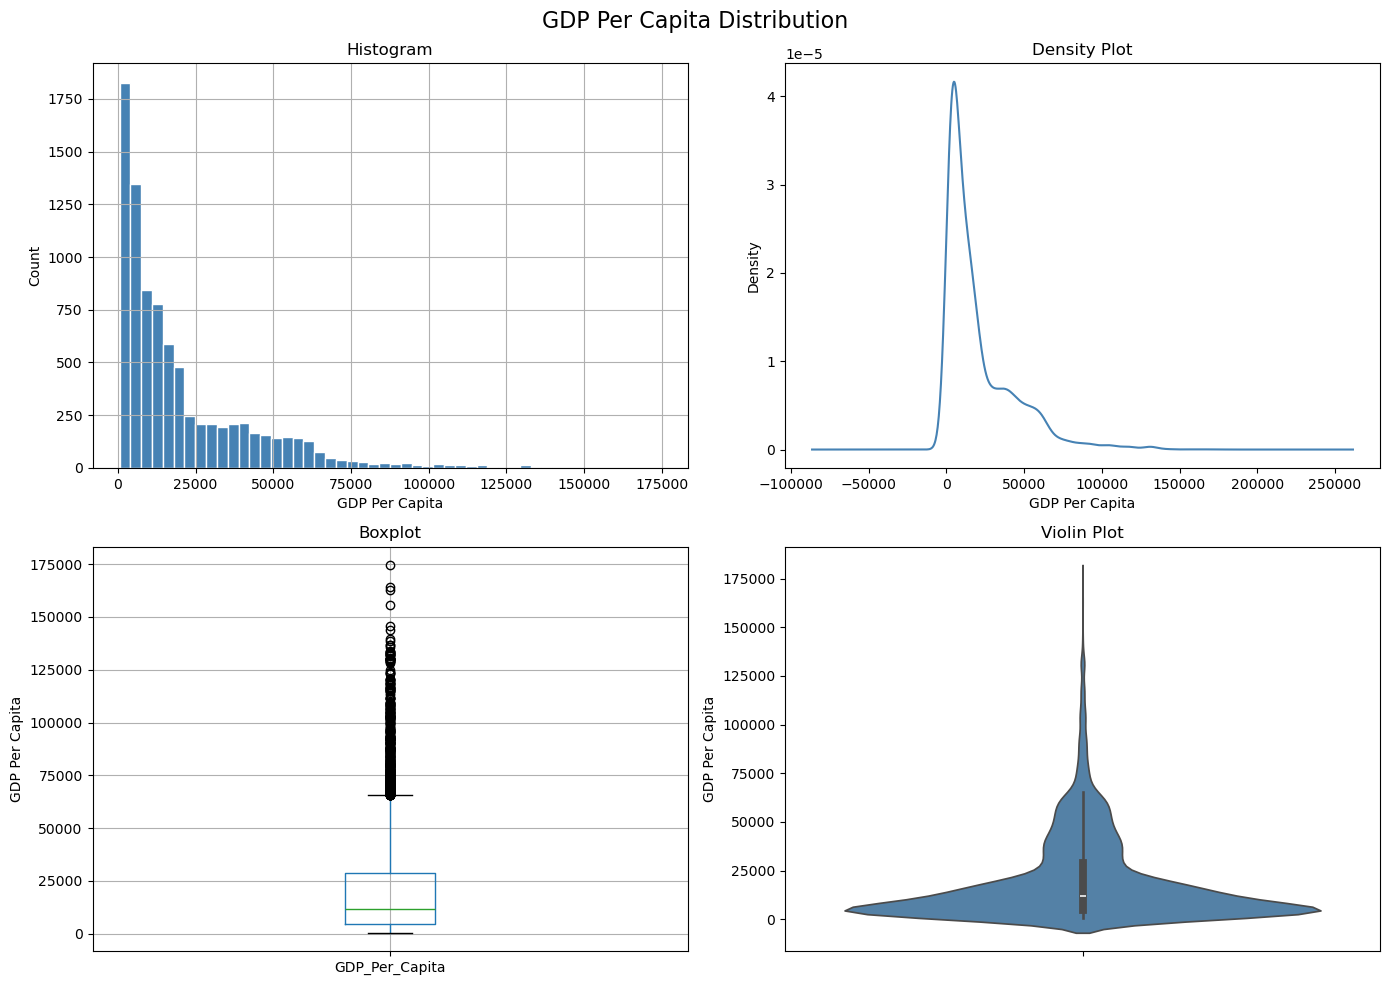

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('GDP Per Capita Distribution', fontsize=16)

# Histogram
gdp_df['GDP_Per_Capita'].hist(bins=50, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Histogram')
axes[0,0].set_xlabel('GDP Per Capita')
axes[0,0].set_ylabel('Count')

# Density plot
gdp_df['GDP_Per_Capita'].plot.kde(ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Density Plot')
axes[0,1].set_xlabel('GDP Per Capita')
axes[0,1].set_ylabel('Density')

# Boxplot
gdp_df.boxplot(column='GDP_Per_Capita', ax=axes[1,0])
axes[1,0].set_title('Boxplot')
axes[1,0].set_ylabel('GDP Per Capita')

# Violin plot
sns.violinplot(y=gdp_df['GDP_Per_Capita'], ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Violin Plot')
axes[1,1].set_ylabel('GDP Per Capita')

plt.tight_layout()
plt.show()

Global GDP per capita is extremely unequal — a few very wealthy countries skew the data significantly. The median is a much better measure of the "typical" country than the mean, which gets pulled up by outliers.

What was the median GDP per capita value in 2020?

In [116]:
gdp_df[gdp_df['Year']==2020]['GDP_Per_Capita'].median()

15399.308958012449

Start by subsetting your data to just these 4 years into a new DataFrame named gdp_decades. Using this, create the following 4 plots:

A boxplot
A barplot
A scatterplot
A scatterplot with a trend line overlaid

Comment on what you observe has happened to GDP values over time and the relative strengths and weaknesses of each type of plot.

Which country was the first to have a GDP per capita greater than $100,000?

Which country had the highest GDP per capita in 2020? Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset.

Which country had the lowest GDP per capita in 2020? Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset. Bonus question: Is it true in general that coutries had a higher GDP per capita in 2020 than in 1990? Which countries had lower GDP per capita in 2020 than in 1990?